# COMPAS Algorithmic Bias Audit
## Introduction
COMPAS is a proprietary risk-assessment tool used in U.S. criminal-justice settings, especially by judges, probation officers, and correctional agencies to estimate recidivism risk. This project investigates whether COMPAS produces racially disparate error rates and unfairly labels people as higher risk. The data comes from ProPublica’s cleaned Broward County, Florida COMPAS dataset, assembled from court records and COMPAS screening records. I computed recidivism-related error metrics, false positive and false negative rates, because they show how often the system over- or under-predicts risk across groups.


In [ ]:
import pandas as pd
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
df = pd.read_csv(url)

df.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [ ]:
df.columns.tolist()

['id',
 'name',
 'first',
 'last',
 'compas_screening_date',
 'sex',
 'dob',
 'age',
 'age_cat',
 'race',
 'juv_fel_count',
 'decile_score',
 'juv_misd_count',
 'juv_other_count',
 'priors_count',
 'days_b_screening_arrest',
 'c_jail_in',
 'c_jail_out',
 'c_case_number',
 'c_offense_date',
 'c_arrest_date',
 'c_days_from_compas',
 'c_charge_degree',
 'c_charge_desc',
 'is_recid',
 'r_case_number',
 'r_charge_degree',
 'r_days_from_arrest',
 'r_offense_date',
 'r_charge_desc',
 'r_jail_in',
 'r_jail_out',
 'violent_recid',
 'is_violent_recid',
 'vr_case_number',
 'vr_charge_degree',
 'vr_offense_date',
 'vr_charge_desc',
 'type_of_assessment',
 'decile_score.1',
 'score_text',
 'screening_date',
 'v_type_of_assessment',
 'v_decile_score',
 'v_score_text',
 'v_screening_date',
 'in_custody',
 'out_custody',
 'priors_count.1',
 'start',
 'end',
 'event',
 'two_year_recid']

In [ ]:
# keep only relevant columns
df_subset = df[['race', 'two_year_recid', 'score_text']]

# keep only Black and White for comparison
df_subset = df_subset[df_subset['race'].isin(['African-American', 'Caucasian'])]

df_subset.head()

,race,two_year_recid,score_text
1,African-American,1,Low
2,African-American,1,Low
3,African-American,0,High
6,Caucasian,1,Medium
8,Caucasian,0,Low


In [ ]:
# Create False Positive Indicator (1 = yes, 0 = no)
df_subset['false_positive'] = (
    (df_subset['two_year_recid'] == 0) &
    (df_subset['score_text'] != 'Low')
).astype(int)

df_subset.head()

,race,two_year_recid,score_text,false_positive
1,African-American,1,Low,0
2,African-American,1,Low,0
3,African-American,0,High,1
6,Caucasian,1,Medium,0
8,Caucasian,0,Low,0


In [ ]:
# keep only people who did not reoffend
non_recid = df_subset[df_subset['two_year_recid'] == 0]

# Among them, calculate % Labeled High Risk
fpr_correct = (
    non_recid
    .groupby('race')['score_text']
    .apply(lambda x: (x != 'Low').mean() * 100)
)

fpr_correct

,score_text
race,
African-American,44.846797
Caucasian,23.454301


In [ ]:
# keep only people who did reoffend
recid = df_subset[df_subset['two_year_recid'] == 1]

# Among them, calculate % Labeled Low Risk
fnr_correct = (
    recid
    .groupby('race')['score_text']
    .apply(lambda x: (x == 'Low').mean() * 100)
)

fnr_correct

,score_text
race,
African-American,27.985271
Caucasian,47.722567


In [ ]:
print(df_subset['race'].value_counts())

race
African-American    3696
Caucasian           2454
Name: count, dtype: int64


## Key Findings
Across 3,696 African-American defendants and 2,454 Caucasian defendants, the false positive rate was 44.8% for African-American defendants and 23.5% for Caucasian defendants, meaning Black defendants were more often wrongly labeled as likely to reoffend when they did not. The false negative rate was 28.0% for African-American defendants and 47.7% for Caucasian defendants, meaning White defendants were more often wrongly labeled low risk when they later did reoffend. These two findings suggest that the algorithm’s errors are not random; instead, it behaves differently across race groups in a systematic way.

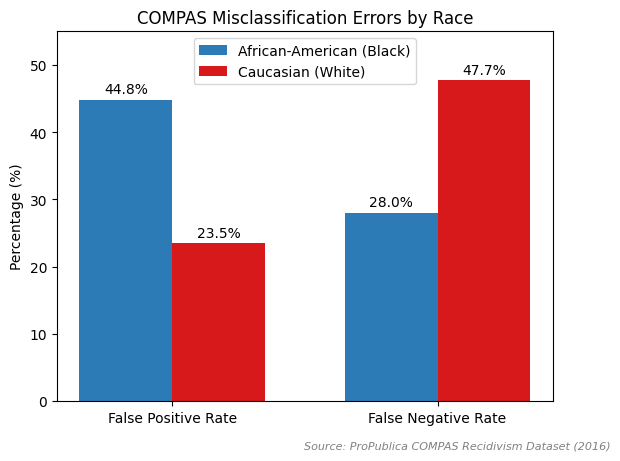

In [ ]:
import matplotlib.pyplot as plt

plt.bar(0 - 0.35/2, fpr_correct['African-American'], 0.35, color='#2C7BB6', label='African-American (Black)')
plt.bar(0 + 0.35/2, fpr_correct['Caucasian'], 0.35, color='#D7191C', label='Caucasian (White)')
plt.bar(1 - 0.35/2, fnr_correct['African-American'], 0.35, color='#2C7BB6')
plt.bar(1 + 0.35/2, fnr_correct['Caucasian'], 0.35, color='#D7191C')
plt.xticks([0, 1], ['False Positive Rate', 'False Negative Rate'])
plt.ylabel('Percentage (%)')
plt.text(0 - 0.35/2, fpr_correct['African-American'] + 1, f"{fpr_correct['African-American']:.1f}%", ha='center')
plt.text(0 + 0.35/2, fpr_correct['Caucasian'] + 1, f"{fpr_correct['Caucasian']:.1f}%", ha='center')
plt.text(1 - 0.35/2, fnr_correct['African-American'] + 1, f"{fnr_correct['African-American']:.1f}%", ha='center')
plt.text(1 + 0.35/2, fnr_correct['Caucasian'] + 1, f"{fnr_correct['Caucasian']:.1f}%", ha='center')
plt.title('COMPAS Misclassification Errors by Race')

plt.legend()
plt.ylim(0, 55)
plt.figtext(0.99, 0.01, 'Source: ProPublica COMPAS Recidivism Dataset (2016)',
            ha='right', fontsize=8, color='grey', style='italic')
plt.savefig('compas_bias_chart.png', dpi=300, bbox_inches='tight')

plt.show()

## Policy Implications
In the real world, this bias means some defendants are more likely to be unfairly treated as dangerous and held to stricter conditions, while others may be underestimated and receive less scrutiny than they should. Courts and policymakers should not rely on a single opaque risk score as decisive evidence. Such tools should be permitted only if they pass independent public audit, their methodology can be challenged, and they serve only as limited inputs alongside human judgment. If they cannot meet those conditions, they should not guide sentencing or pretrial detention decisions.